In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

BASE_DIR = "D:/" 



train0_path = BASE_DIR + "Traindata_0.txt"
train1_path = BASE_DIR + "Traindata_1.txt"

import os
print("فایل train0 وجود دارد؟", os.path.exists(train0_path))
print("فایل train1 وجود دارد؟", os.path.exists(train1_path))

فایل train0 وجود دارد؟ True
فایل train1 وجود دارد؟ True


In [2]:
N_CHANNELS = 6
N_SAMPLES = 896

def load_train_file(path):
    data = np.loadtxt(path)
    y = data[:, 0].astype(np.int32)
    X = data[:, 1:]
    print("shape:", X.shape)
    X = X.reshape(-1, N_CHANNELS, N_SAMPLES)
    return X, y


X0, y0 = load_train_file(train0_path)

X1, y1 = load_train_file(train1_path)

print("shape:", X0.shape)
print("shape:", X1.shape)

shape: (135, 5376)
shape: (133, 5376)
shape: (135, 6, 896)
shape: (133, 6, 896)


In [3]:
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

print("X shape:", X.shape)
print("y shape:", y.shape)


n_trials, n_channels, n_samples = X.shape
X_2d = X.reshape(-1, n_samples)
scaler = StandardScaler()
X_2d = scaler.fit_transform(X_2d)
X = X_2d.reshape(n_trials, n_channels, n_samples)



X shape: (268, 6, 896)
y shape: (268,)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
# داده های بیسیک
print("="*50)
print("Dataset Information")
print("="*50)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass Distribution")
print("Class 0:", np.sum(y == 0))
print("Class 1:", np.sum(y == 1))

print("\nGlobal Statistics")
print("Mean :", np.mean(X))
print("Std  :", np.std(X))
print("Min  :", np.min(X))
print("Max  :", np.max(X))

Dataset Information
X shape: (268, 6, 896)
y shape: (268,)

Class Distribution
Class 0: 135
Class 1: 133

Global Statistics
Mean : 1.0100109961053307e-16
Std  : 1.0
Min  : -3.9134103908770075
Max  : 5.7833784319601005


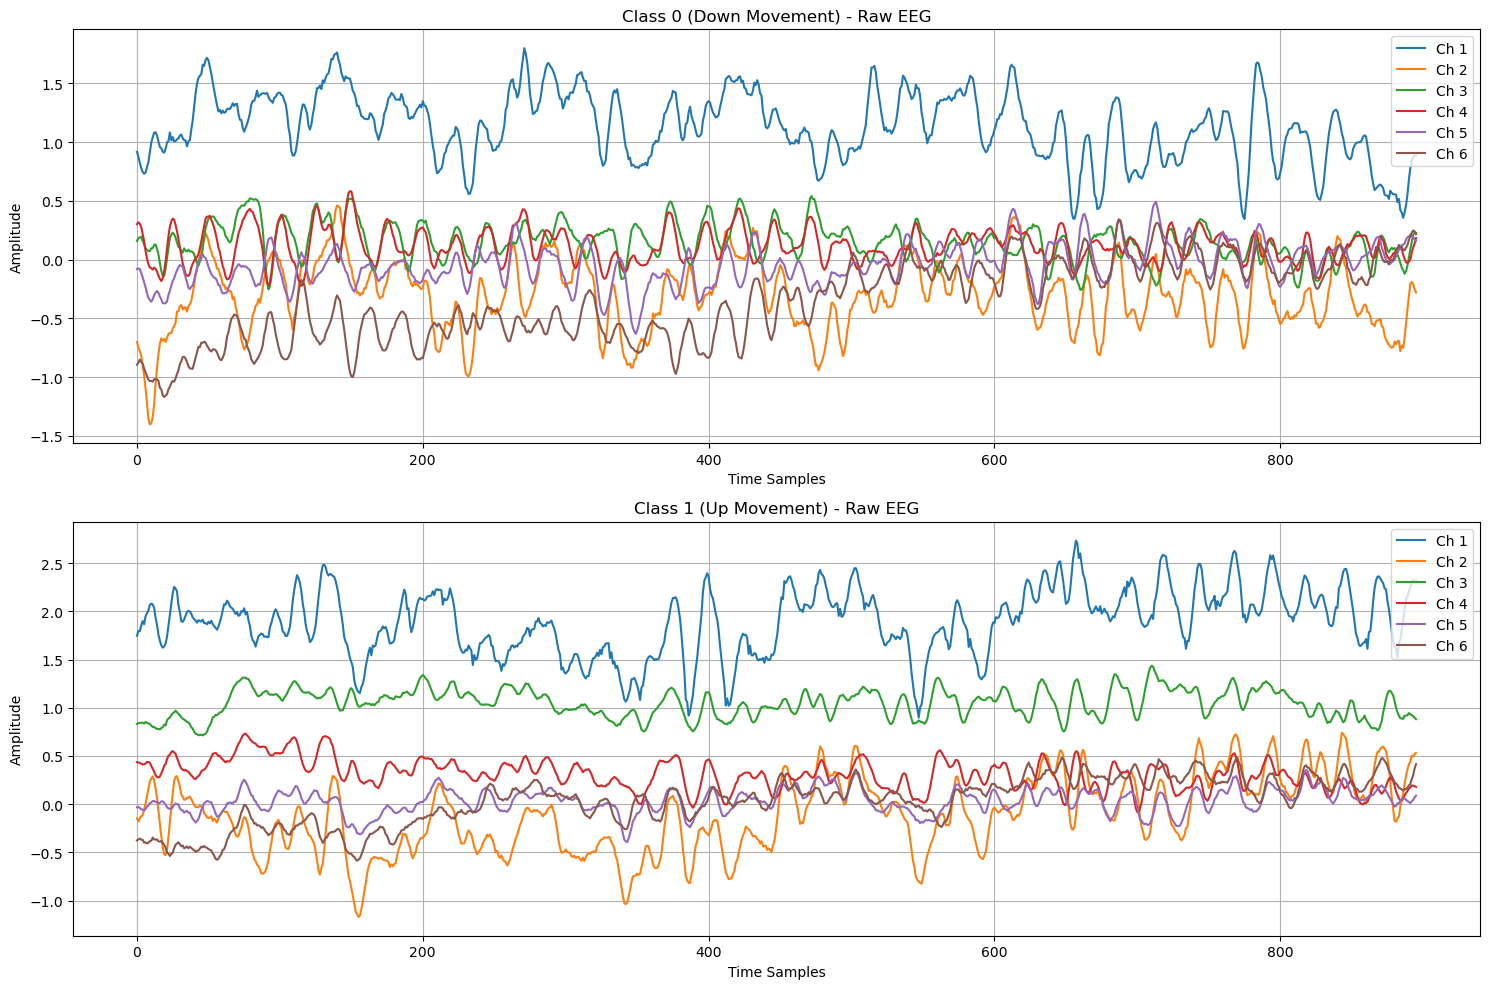

In [5]:
# انتخاب یک نمونه از هر کلاس و رسم نمودارش 

idx0 = np.where(y == 0)[0][134]
idx1 = np.where(y == 1)[0][132]
fig, axes = plt.subplots(2, 1, figsize=(15,10))

for ch in range(6):
    axes[0].plot(X[idx0, ch, :], label=f'Ch {ch+1}')

axes[0].set_title('Class 0 (Down Movement) - Raw EEG')
axes[0].set_xlabel('Time Samples')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True)

for ch in range(6):
    axes[1].plot(X[idx1, ch, :], label=f'Ch {ch+1}')

axes[1].set_title('Class 1 (Up Movement) - Raw EEG')
axes[1].set_xlabel('Time Samples')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# TensorFlow
tf.random.set_seed(SEED)

# Python Hash
os.environ["PYTHONHASHSEED"] = str(SEED)

# Deterministic TensorFlow
tf.config.experimental.enable_op_determinism()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
    shuffle=True
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
    shuffle=True
)

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [9]:
print("\nTrain")

print(np.sum(y_train==0))

print(np.sum(y_train==1))

print("\nValidation")

print(np.sum(y_valid==0))

print(np.sum(y_valid==1))

print("\nTest")

print(np.sum(y_test==0))

print(np.sum(y_test==1))


Train
94
93

Validation
20
20

Test
21
20


In [17]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1
)

In [18]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [19]:
callbacks = [

    early_stop,

    checkpoint

]

In [20]:
def plot_history(history):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)

    plt.plot(history.history['loss'], label='Train')

    plt.plot(history.history['val_loss'], label='Validation')

    plt.title("Loss")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.legend()

    plt.grid(True)

    plt.subplot(1,2,2)

    plt.plot(history.history['accuracy'], label='Train')

    plt.plot(history.history['val_accuracy'], label='Validation')

    plt.title("Accuracy")

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test):

    y_prob = model.predict(X_test)

    y_pred = (y_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    print("="*50)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

In [22]:

# Data for CNN1D

print("Train :", X_train.shape)
print("Validation :", X_valid.shape)
print("Test :", X_test.shape)
X_train_cnn = np.transpose(X_train, (0, 2, 1))
X_valid_cnn = np.transpose(X_valid, (0, 2, 1))
X_test_cnn  = np.transpose(X_test, (0, 2, 1))

Train : (187, 6, 896)
Validation : (40, 6, 896)
Test : (41, 6, 896)


In [23]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Conv1D,

    BatchNormalization,

    MaxPooling1D,

    GlobalAveragePooling1D,

    Dense,

    Dropout

)

from tensorflow.keras.optimizers import Adam

In [24]:
cnn1d = Sequential()

# Block 1

cnn1d.add(

    Conv1D(

        filters=32,

        kernel_size=7,

        activation='relu',

        padding='same',

        input_shape=(896,6)

    )

)

cnn1d.add(BatchNormalization())

cnn1d.add(MaxPooling1D(pool_size=2))

cnn1d.add(Dropout(0.30))

# Block 2

cnn1d.add(

    Conv1D(

        filters=64,

        kernel_size=5,

        activation='relu',

        padding='same'

    )

)

cnn1d.add(BatchNormalization())

cnn1d.add(MaxPooling1D(pool_size=2))

cnn1d.add(Dropout(0.30))

# Block 3

cnn1d.add(

    Conv1D(

        filters=128,

        kernel_size=3,

        activation='relu',

        padding='same'

    )

)

cnn1d.add(BatchNormalization())

cnn1d.add(GlobalAveragePooling1D())

cnn1d.add(Dense(64, activation='relu'))

cnn1d.add(Dropout(0.50))

cnn1d.add(Dense(1, activation='sigmoid'))

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
cnn1d.compile(

    optimizer=Adam(learning_rate=0.001),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [26]:
cnn1d.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 896, 32)        │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 896, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 448, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 448, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 448, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 448, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 224, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 224, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 224, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 224, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,601 (178.13 KB)

 Trainable params: 45,153 (176.38 KB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
history = cnn1d.fit(

    X_train_cnn,

    y_train,

    validation_data=(

        X_valid_cnn,

        y_valid

    ),

    epochs=100,

    batch_size=16,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6203 - loss: 0.6540
Epoch 1: val_accuracy improved from None to 0.62500, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - accuracy: 0.6203 - loss: 0.6540 - val_accuracy: 0.6250 - val_loss: 0.6475
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7807 - loss: 0.4818
Epoch 2: val_accuracy improved from 0.62500 to 0.72500, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.7807 - loss: 0.4818 - val_accuracy: 0.7250 - val_loss: 0.6391
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7968 - loss: 0.4228
Epoch 3: val_accuracy improved from 0.72500 to 0.77500, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.7968 - loss: 0.4228 - val_accuracy:

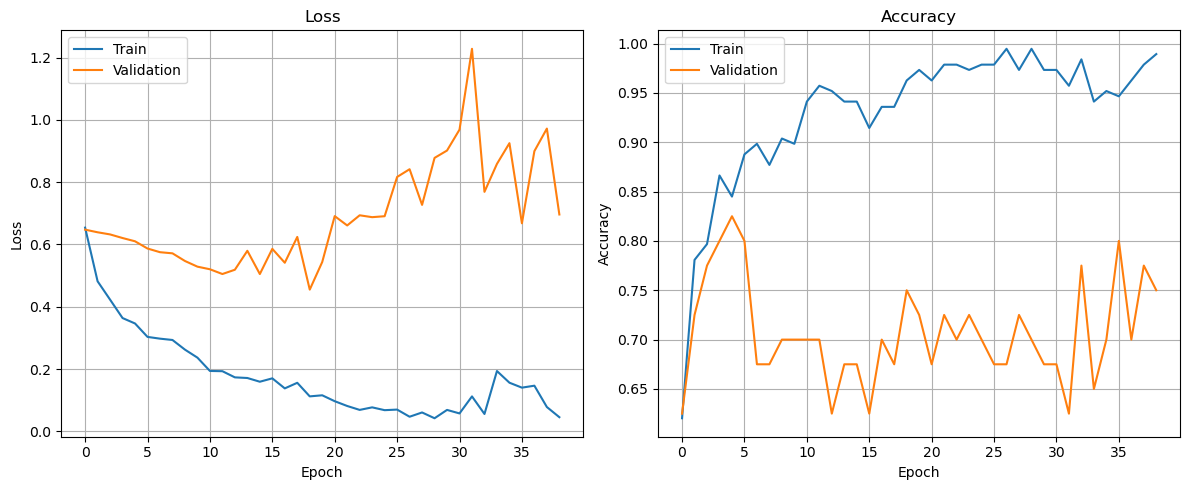

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step
Accuracy : 0.7073
Precision: 0.6250
Recall   : 1.0000
F1 Score : 0.7692

Confusion Matrix
[[ 9 12]
 [ 0 20]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.43      0.60        21
           1       0.62      1.00      0.77        20

    accuracy                           0.71        41
   macro avg       0.81      0.71      0.68        41
weighted avg       0.82      0.71      0.68        41



In [28]:
plot_history(history)
evaluate_model(

    cnn1d,

    X_test_cnn,

    y_test

)

In [29]:
# Data for EEGNet
# برای EEGNet و DeepConvNet
X_train_eeg = X_train[..., np.newaxis]
X_valid_eeg = X_valid[..., np.newaxis]
X_test_eeg  = X_test[..., np.newaxis]


print(X_train_eeg.shape)
print(X_valid_eeg.shape)
print(X_test_eeg.shape)

(187, 6, 896, 1)
(40, 6, 896, 1)
(41, 6, 896, 1)


In [30]:
from tensorflow.keras.models import Model

from tensorflow.keras.layers import (

    Input,

    Conv2D,

    DepthwiseConv2D,

    SeparableConv2D,

    BatchNormalization,

    AveragePooling2D,

    Dropout,

    Flatten,

    Dense,

    Activation

)

from tensorflow.keras.constraints import max_norm

In [31]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    SeparableConv2D,
    BatchNormalization,
    AveragePooling2D,
    Dropout,
    Flatten,
    Dense,
    Activation
)
from tensorflow.keras.constraints import max_norm

# EEGNet 

input1 = Input(shape=(6,896,1))


# Block 1

x = Conv2D(
    filters=8,
    kernel_size=(1,64),
    padding='same',
    use_bias=False
)(input1)

x = BatchNormalization()(x)

x = DepthwiseConv2D(
    kernel_size=(6,1),
    depth_multiplier=2,
    use_bias=False,
    depthwise_constraint=max_norm(1.)
)(x)

x = BatchNormalization()(x)

x = Activation('elu')(x)

x = AveragePooling2D(
    pool_size=(1,4)
)(x)

x = Dropout(0.5)(x)

# Block 2


x = SeparableConv2D(
    filters=16,
    kernel_size=(1,16),
    padding='same',
    use_bias=False
)(x)

x = BatchNormalization()(x)

x = Activation('elu')(x)

x = AveragePooling2D(
    pool_size=(1,8)
)(x)

x = Dropout(0.5)(x)

# Classification

x = Flatten()(x)

output = Dense(
    1,
    activation='sigmoid',
    kernel_constraint=max_norm(0.25)
)(x)

eegnet = Model(
    inputs=input1,
    outputs=output
)

eegnet.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 6, 896, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 6, 896, 8)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 896, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 896, 16)     │            96 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 896, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 896, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 224, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 224, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 224, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 224, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 224, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 28, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 28, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           449 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,729 (6.75 KB)

 Trainable params: 1,649 (6.44 KB)

 Non-trainable params: 80 (320.00 B)

In [32]:
from tensorflow.keras.optimizers import Adam

eegnet.compile(

    optimizer=Adam(0.001),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [33]:
history = eegnet.fit(

    X_train_eeg,

    y_train,

    validation_data=(

        X_valid_eeg,

        y_valid

    ),

    epochs=100,

    batch_size=16,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5909 - loss: 0.6827
Epoch 1: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.6096 - loss: 0.6739 - val_accuracy: 0.7250 - val_loss: 0.6792
Epoch 2/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7159 - loss: 0.5864
Epoch 2: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7326 - loss: 0.5740 - val_accuracy: 0.7750 - val_loss: 0.6535
Epoch 3/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7330 - loss: 0.5294
Epoch 3: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7487 - loss: 0.5170 - val_accuracy: 0.8000 - val_loss: 0.6231
Epoch 4/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7784 - loss: 0.5002
Epoch 4: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.7914 - loss: 0.4883 - val_accuracy: 0.8000 - val_l

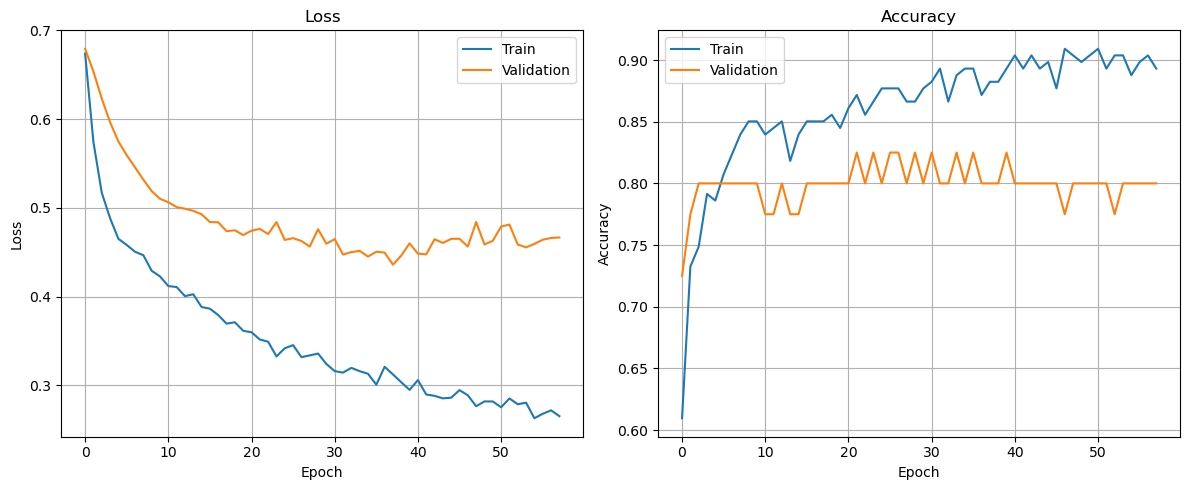

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Accuracy : 0.8537
Precision: 0.8500
Recall   : 0.8500
F1 Score : 0.8500

Confusion Matrix
[[18  3]
 [ 3 17]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        21
           1       0.85      0.85      0.85        20

    accuracy                           0.85        41
   macro avg       0.85      0.85      0.85        41
weighted avg       0.85      0.85      0.85        41



In [34]:
plot_history(history)

evaluate_model(
    eegnet,
    X_test_eeg,
    y_test
)

In [35]:
from tensorflow.keras.models import Model

from tensorflow.keras.layers import *

from tensorflow.keras.constraints import max_norm

from tensorflow.keras.regularizers import l2

In [36]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    Activation,
    MaxPooling2D,
    Dropout,
    Flatten,
    Dense
)
from tensorflow.keras.constraints import max_norm


# DeepConvNet


inputs = Input(shape=(6,896,1))

# Block 1


x = Conv2D(
    25,
    (1,5),
    padding='same',
    use_bias=False
)(inputs)

x = Conv2D(
    25,
    (6,1),
    use_bias=False
)(x)

x = BatchNormalization()(x)

x = Activation('elu')(x)

x = MaxPooling2D(
    pool_size=(1,2)
)(x)

x = Dropout(0.5)(x)


# Block 2


x = Conv2D(
    50,
    (1,5),
    padding='same',
    use_bias=False
)(x)

x = BatchNormalization()(x)

x = Activation('elu')(x)

x = MaxPooling2D(
    pool_size=(1,2)
)(x)

x = Dropout(0.5)(x)


# Block 3


x = Conv2D(
    100,
    (1,5),
    padding='same',
    use_bias=False
)(x)

x = BatchNormalization()(x)

x = Activation('elu')(x)

x = MaxPooling2D(
    pool_size=(1,2)
)(x)

x = Dropout(0.5)(x)


# Block 4


x = Conv2D(
    200,
    (1,5),
    padding='same',
    use_bias=False
)(x)

x = BatchNormalization()(x)

x = Activation('elu')(x)

x = MaxPooling2D(
    pool_size=(1,2)
)(x)

x = Dropout(0.5)(x)


# Classification


x = Flatten()(x)

outputs = Dense(
    1,
    activation='sigmoid',
    kernel_constraint=max_norm(0.5)
)(x)

deepconvnet = Model(
    inputs,
    outputs
)

deepconvnet.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 6, 896, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 896, 25)     │           125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 896, 25)     │         3,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1, 896, 25)     │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1, 896, 25)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 448, 25)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 448, 25)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 448, 50)     │         6,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1, 448, 50)     │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 448, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 224, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 224, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 224, 100)    │        25,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1, 224, 100)    │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1, 224, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 112, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 112, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 1, 112, 200)    │       100,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1, 112, 200)    │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 1, 112, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 56, 200)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 56, 200)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 11200)          │             

 Total params: 147,826 (577.45 KB)

 Trainable params: 147,076 (574.52 KB)

 Non-trainable params: 750 (2.93 KB)

In [37]:
from tensorflow.keras.optimizers import Adam

deepconvnet.compile(

    optimizer=Adam(1e-3),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [38]:
history = deepconvnet.fit(

    X_train_eeg,

    y_train,

    validation_data=(

        X_valid_eeg,

        y_valid

    ),

    epochs=100,

    batch_size=16,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6738 - loss: 0.7125
Epoch 1: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.6738 - loss: 0.7125 - val_accuracy: 0.7250 - val_loss: 0.5648
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7487 - loss: 0.5599
Epoch 2: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7487 - loss: 0.5599 - val_accuracy: 0.7500 - val_loss: 0.5577
Epoch 3/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7386 - loss: 0.5741
Epoch 3: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7540 - loss: 0.5513 - val_accuracy: 0.7500 - val_loss: 0.6547
Epoch 4/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8466 - loss: 0.4478
Epoch 4: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.8396 - loss: 0.4418 - val_accuracy: 0.8250 - val_

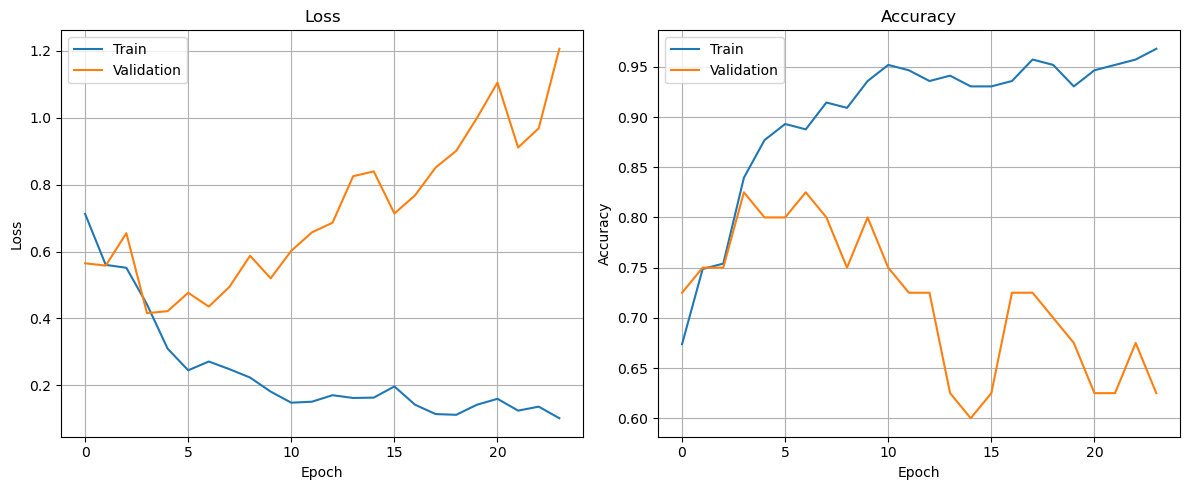

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000020F36D5B920> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step
Accuracy : 0.7805
Precision: 0.8667
Recall   : 0.6500
F1 Score : 0.7429

Confusion Matrix
[[19  2]
 [ 7 13]]

Classification Report
              precision    recall  f1-score   support

          

In [39]:
plot_history(history)

evaluate_model(

    deepconvnet,

    X_test_eeg,

    y_test

)

In [40]:
from tensorflow.keras.layers import *

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

In [41]:
from tensorflow.keras.layers import (
    Conv1D,
    BatchNormalization,
    Activation,
    Add
)

def residual_block(x, filters):

    shortcut = x

    x = Conv1D(
        filters,
        kernel_size=3,
        padding='same'
    )(x)

    x = BatchNormalization()(x)

    x = Activation('relu')(x)

    x = Conv1D(
        filters,
        kernel_size=3,
        padding='same'
    )(x)

    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:

        shortcut = Conv1D(
            filters,
            kernel_size=1,
            padding='same'
        )(shortcut)

    x = Add()([x, shortcut])

    x = Activation('relu')(x)

    return x

In [42]:
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

inputs = Input(shape=(896,6))

x = Conv1D(
    32,
    kernel_size=7,
    padding='same',
    activation='relu'
)(inputs)

x = BatchNormalization()(x)


# Residual Block 1


x = residual_block(x,32)


# Residual Block 2


x = residual_block(x,64)


# Residual Block 3


x = residual_block(x,128)



x = GlobalAveragePooling1D()(x)

x = Dropout(0.5)(x)

outputs = Dense(
    1,
    activation='sigmoid'
)(x)

resnet = Model(
    inputs,
    outputs
)

resnet.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 896, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 896, 32)   │      1,376 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 896, 32)   │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 896, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 896, 32)   │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 896, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 896, 32)   │      3,104 │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 896, 32)   │        128 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 896, 32)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 896, 32)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 896, 64)   │      6,208 │ activation_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 896, 64)   │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 896, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 896, 64)   │     12,352 │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 896, 64)   │        256 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 896, 64)   │      2,112 │ activation_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 896, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 896, 64)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 896, 128)  │     24,704 │ activation_9[0][

 Total params: 112,609 (439.88 KB)

 Trainable params: 111,649 (436.13 KB)

 Non-trainable params: 960 (3.75 KB)

In [43]:
resnet.compile(

    optimizer=Adam(1e-3),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [44]:
history = resnet.fit(

    X_train_cnn,

    y_train,

    validation_data=(

        X_valid_cnn,

        y_valid

    ),

    epochs=100,

    batch_size=16,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5775 - loss: 0.7492
Epoch 1: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 246ms/step - accuracy: 0.5775 - loss: 0.7492 - val_accuracy: 0.7750 - val_loss: 0.6287
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7914 - loss: 0.4585
Epoch 2: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.7914 - loss: 0.4585 - val_accuracy: 0.7750 - val_loss: 0.6089
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8610 - loss: 0.3543
Epoch 3: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.8610 - loss: 0.3543 - val_accuracy: 0.7750 - val_loss: 0.5874
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8770 - loss: 0.2790
Epoch 4: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.8770 - loss: 0.2790 - val_accuracy: 0.800

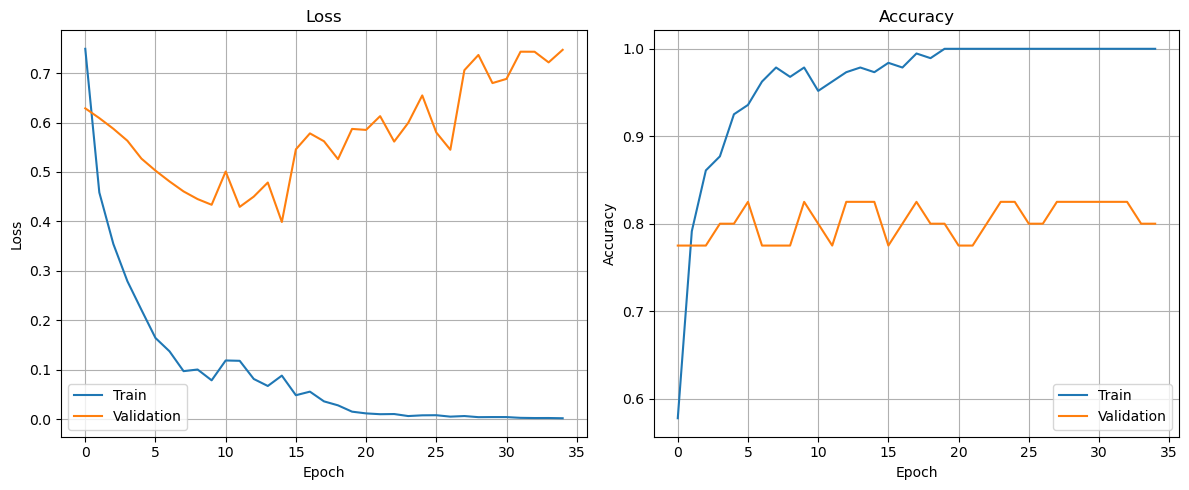

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
Accuracy : 0.7805
Precision: 0.7391
Recall   : 0.8500
F1 Score : 0.7907

Confusion Matrix
[[15  6]
 [ 3 17]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        21
           1       0.74      0.85      0.79        20

    accuracy                           0.78        41
   macro avg       0.79      0.78      0.78        41
weighted avg       0.79      0.78      0.78        41



In [45]:
plot_history(history)

evaluate_model(

    resnet,

    X_test_cnn,

    y_test

)

In [59]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.optimizers import Adam

In [46]:
cnn_lstm = Sequential()

# Block 1

cnn_lstm.add(

    Conv1D(

        filters=32,

        kernel_size=7,

        activation='relu',

        padding='same',

        input_shape=(896,6)

    )

)

cnn_lstm.add(

    BatchNormalization()

)

cnn_lstm.add(

    MaxPooling1D(2)

)

# Block 2

cnn_lstm.add(

    Conv1D(

        filters=64,

        kernel_size=5,

        activation='relu',

        padding='same'

    )

)

cnn_lstm.add(

    BatchNormalization()

)

cnn_lstm.add(

    MaxPooling1D(2)

)

# LSTM

cnn_lstm.add(

    LSTM(

        64,

        return_sequences=False

    )

)

cnn_lstm.add(

    Dropout(0.5)

)

# Output

cnn_lstm.add(

    Dense(

        1,

        activation='sigmoid'

    )

)

cnn_lstm.summary()

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 896, 32)        │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 896, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 448, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 448, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 448, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 224, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,153 (176.38 KB)

 Trainable params: 44,961 (175.63 KB)

 Non-trainable params: 192 (768.00 B)

In [47]:
cnn_lstm.compile(

    optimizer=Adam(1e-3),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [48]:
history = cnn_lstm.fit(

    X_train_cnn,

    y_train,

    validation_data=(

        X_valid_cnn,

        y_valid

    ),

    epochs=100,

    batch_size=16,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5455 - loss: 0.6979
Epoch 1: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 221ms/step - accuracy: 0.5455 - loss: 0.6979 - val_accuracy: 0.6500 - val_loss: 0.6508
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7326 - loss: 0.5403
Epoch 2: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.7326 - loss: 0.5403 - val_accuracy: 0.6750 - val_loss: 0.6336
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8021 - loss: 0.4978
Epoch 3: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.8021 - loss: 0.4978 - val_accuracy: 0.6500 - val_loss: 0.6254
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8182 - loss: 0.4623
Epoch 4: val_accuracy did not improve from 0.82500
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.8182 - loss: 0.4623 - val_accuracy: 0.7250 

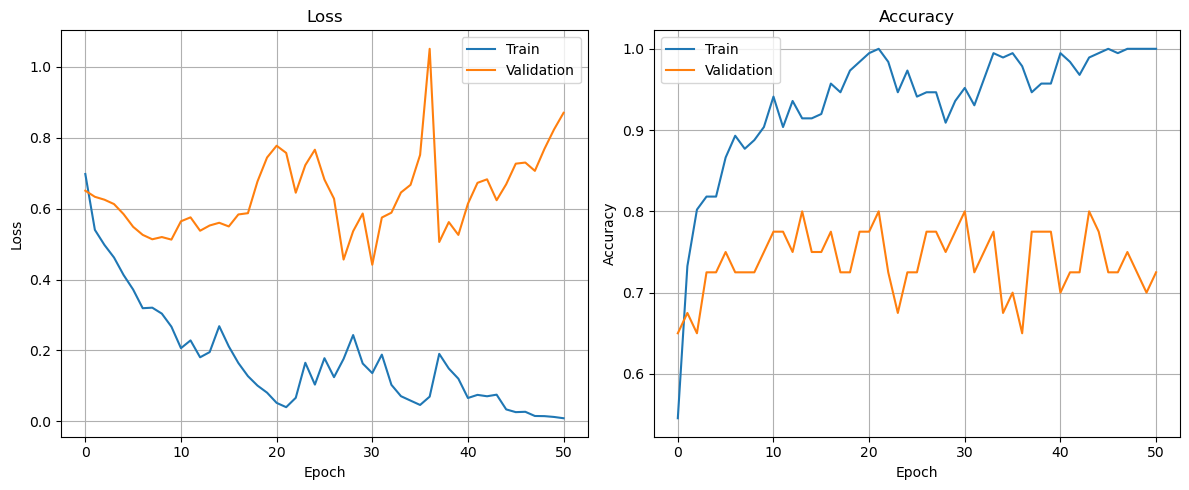

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 440ms/step
Accuracy : 0.6829
Precision: 0.6207
Recall   : 0.9000
F1 Score : 0.7347

Confusion Matrix
[[10 11]
 [ 2 18]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.48      0.61        21
           1       0.62      0.90      0.73        20

    accuracy                           0.68        41
   macro avg       0.73      0.69      0.67        41
weighted avg       0.73      0.68      0.67        41



In [49]:
plot_history(history)

evaluate_model(

    cnn_lstm,

    X_test_cnn,

    y_test

)

In [60]:
import numpy as np
import matplotlib.pyplot as plt

In [62]:
def add_noise(X, noise_std=0.05):

    noise = np.random.normal(
        loc=0,
        scale=noise_std,
        size=X.shape
    )

    return X + noise

X_train_noise = add_noise(
    X_train,
    noise_std=0.05
)

In [63]:
def scaling(X, low=0.9, high=1.1):

    scale = np.random.uniform(
        low,
        high,
        size=(X.shape[0],1,1)
    )

    return X * scale

X_train_scale = scaling(
    X_train,
    low=0.9,
    high=1.1
)

In [64]:
def time_shift(X, max_shift=20):

    X_new = np.empty_like(X)

    for i in range(len(X)):

        shift = np.random.randint(
            -max_shift,
            max_shift+1
        )

        X_new[i] = np.roll(
            X[i],
            shift,
            axis=1
        )

    return X_new

X_train_shift = time_shift(
    X_train,
    max_shift=20
)

In [65]:
X_train_aug = np.concatenate(

    [

        X_train,

        X_train_noise,

        X_train_scale,

        X_train_shift

    ],

    axis=0

)

y_train_aug = np.concatenate(

    [

        y_train,

        y_train,

        y_train,

        y_train

    ],

    axis=0
)

In [67]:


print(X_train.shape)
print(X_train_aug.shape)

print(y_train.shape)
print(y_train_aug.shape)

(187, 6, 896)
(748, 6, 896)
(187,)
(748,)


In [68]:
X_train_aug_eeg = X_train_aug[..., np.newaxis]

X_valid_eeg = X_valid[..., np.newaxis]

X_test_eeg = X_test[..., np.newaxis]

In [69]:
print(X_train_aug_eeg.shape)

print(X_valid_eeg.shape)

print(X_test_eeg.shape)

(748, 6, 896, 1)
(40, 6, 896, 1)
(41, 6, 896, 1)


In [70]:
print(np.unique(y_train_aug, return_counts=True))

(array([0, 1], dtype=int32), array([376, 372]))


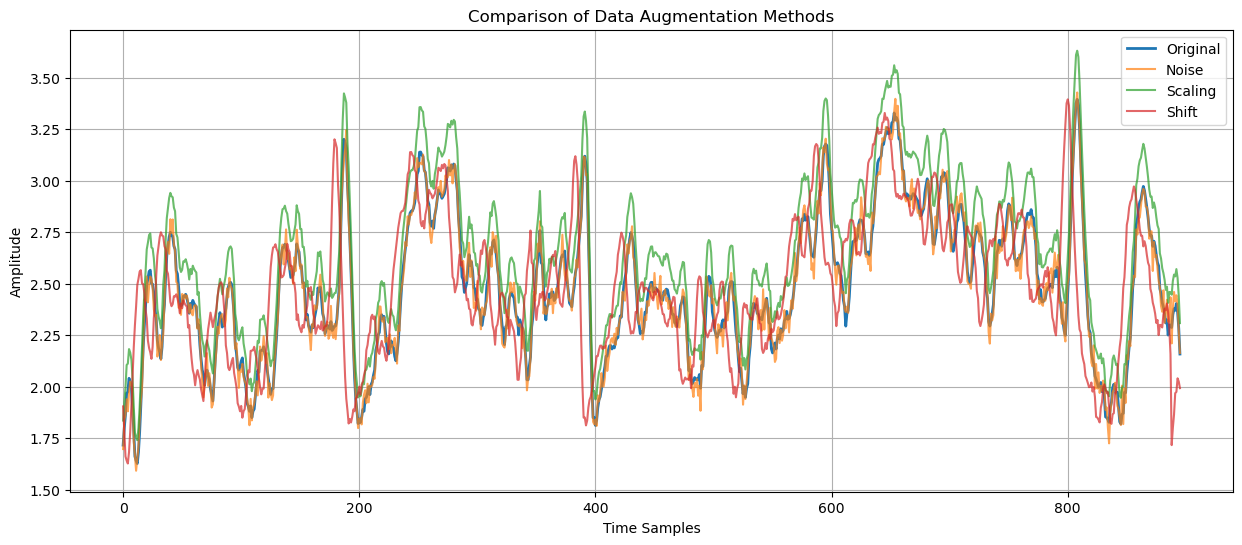

In [71]:
plt.figure(figsize=(15,6))

plt.plot(
    X_train[trial, channel],
    label="Original",
    linewidth=2
)

plt.plot(
    X_train_noise[trial, channel],
    label="Noise",
    alpha=0.7
)

plt.plot(
    X_train_scale[trial, channel],
    label="Scaling",
    alpha=0.7
)

plt.plot(
    X_train_shift[trial, channel],
    label="Shift",
    alpha=0.7
)

plt.legend()

plt.grid(True)

plt.title("Comparison of Data Augmentation Methods")

plt.xlabel("Time Samples")

plt.ylabel("Amplitude")

plt.show()

In [56]:
X_train_aug_eeg = X_train_aug[..., np.newaxis]

X_val_eeg = X_valid[..., np.newaxis]

X_test_eeg = X_test[..., np.newaxis]

In [73]:
from tensorflow.keras.models import Model

from tensorflow.keras.layers import (

    Input,

    Conv2D,

    DepthwiseConv2D,

    SeparableConv2D,

    BatchNormalization,

    AveragePooling2D,

    Dropout,

    Flatten,

    Dense,

    Activation

)

from tensorflow.keras.constraints import max_norm

In [74]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    SeparableConv2D,
    BatchNormalization,
    AveragePooling2D,
    Dropout,
    Flatten,
    Dense,
    Activation
)
from tensorflow.keras.constraints import max_norm

# EEGNet 


input1 = Input(shape=(6,896,1))

# Block 1


x = Conv2D(
    filters=8,
    kernel_size=(1,64),
    padding='same',
    use_bias=False
)(input1)

x = BatchNormalization()(x)

x = DepthwiseConv2D(
    kernel_size=(6,1),
    depth_multiplier=2,
    use_bias=False,
    depthwise_constraint=max_norm(1.)
)(x)

x = BatchNormalization()(x)

x = Activation('elu')(x)

x = AveragePooling2D(
    pool_size=(1,4)
)(x)

x = Dropout(0.5)(x)

# Block 2

x = SeparableConv2D(
    filters=16,
    kernel_size=(1,16),
    padding='same',
    use_bias=False
)(x)

x = BatchNormalization()(x)

x = Activation('elu')(x)

x = AveragePooling2D(
    pool_size=(1,8)
)(x)

x = Dropout(0.5)(x)

# Classification

x = Flatten()(x)

output = Dense(
    1,
    activation='sigmoid',
    kernel_constraint=max_norm(0.25)
)(x)

eegnetagu = Model(
    inputs=input1,
    outputs=output
)

eegnetagu.summary()

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 6, 896, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 896, 8)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 6, 896, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 1, 896, 16)     │            96 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 1, 896, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 1, 896, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 224, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1, 224, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 1, 224, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 1, 224, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 1, 224, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 1, 28, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 28, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           449 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,729 (6.75 KB)

 Trainable params: 1,649 (6.44 KB)

 Non-trainable params: 80 (320.00 B)

In [75]:
from tensorflow.keras.optimizers import Adam

eegnet.compile(

    optimizer=Adam(0.001),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [81]:
history = eegnetagu.fit(

    X_train_aug,

    y_train_aug,

    validation_data=(

        X_valid_eeg,

        y_valid

    ),

    epochs=100,

    batch_size=16,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6631 - loss: 0.5847
Epoch 1: val_accuracy did not improve from 0.85000
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.6631 - loss: 0.5847 - val_accuracy: 0.8000 - val_loss: 0.6100
Epoch 2/100
46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7717 - loss: 0.4963
Epoch 2: val_accuracy did not improve from 0.85000
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.7714 - loss: 0.4945 - val_accuracy: 0.7500 - val_loss: 0.5714
Epoch 3/100
46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8125 - loss: 0.4563
Epoch 3: val_accuracy did not improve from 0.85000
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8128 - loss: 0.4550 - val_accuracy: 0.7500 - val_loss: 0.5391
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8329 - loss: 0.4209
Epoch 4: val_accuracy did not improve from 0.85000
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8329 - loss: 0.4209 - val_accuracy: 0.7500 - val_l

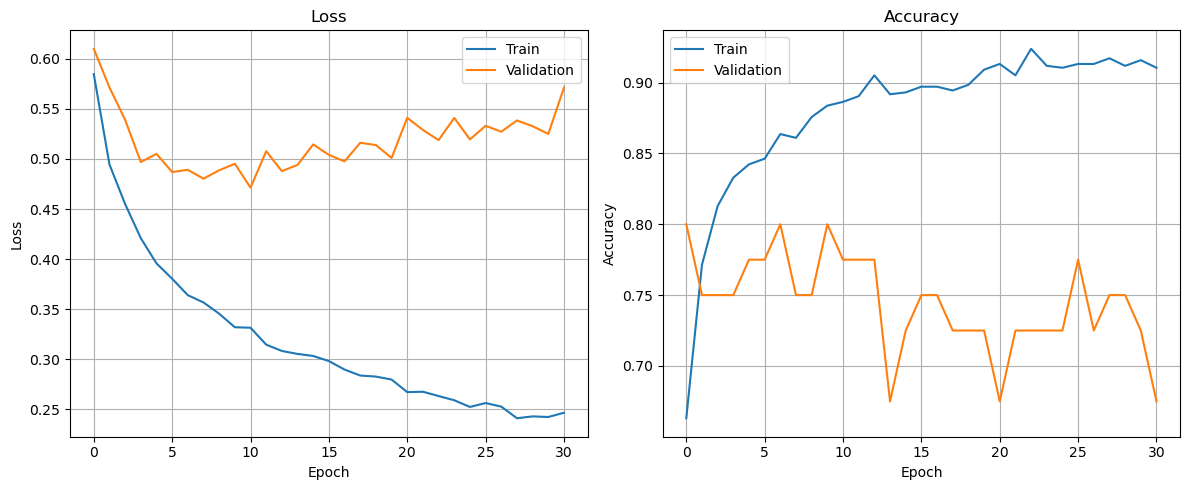

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Accuracy : 0.8293
Precision: 0.8095
Recall   : 0.8500
F1 Score : 0.8293

Confusion Matrix
[[17  4]
 [ 3 17]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.81      0.83        21
           1       0.81      0.85      0.83        20

    accuracy                           0.83        41
   macro avg       0.83      0.83      0.83        41
weighted avg       0.83      0.83      0.83        41



In [82]:
plot_history(history)

evaluate_model(
    eegnetagu,
    X_test_eeg,
    y_test
)

In [118]:
import numpy as np

In [119]:
def extract_fft(X):

    features = []

    for trial in X:

        trial_feature = []

        for ch in range(trial.shape[0]):

            fft = np.abs(np.fft.rfft(trial[ch]))

            trial_feature.extend(fft)

        features.append(trial_feature)

    return np.array(features)

In [120]:
X_train_fft = extract_fft(X_train)

X_valid_fft = extract_fft(X_valid)

X_test_fft = extract_fft(X_test)

In [121]:
print(X_train_fft.shape)

print(X_valid_fft.shape)

print(X_test_fft.shape)

(187, 2694)
(40, 2694)
(41, 2694)


In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_fft = scaler.fit_transform(X_train_fft)

X_valid_fft = scaler.transform(X_valid_fft)

X_test_fft = scaler.transform(X_test_fft)

In [123]:
X_train_eeg = X_train[..., np.newaxis]

X_valid_eeg = X_valid[..., np.newaxis]

X_test_eeg = X_test[..., np.newaxis]

In [124]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.optimizers import Adam

In [125]:
eeg_input = Input(

    shape=(6,896,1),

    name="EEG"

)
fft_input = Input(

    shape=(2694,),

    name="FFT"

)


In [126]:
x = Conv2D(
    8,
    (1,64),
    padding="same",
    use_bias=False
)(eeg_input)

x = BatchNormalization()(x)

x = DepthwiseConv2D(
    (6,1),
    depth_multiplier=2,
    use_bias=False,
    depthwise_constraint=max_norm(1.)
)(x)

x = BatchNormalization()(x)

x = Activation("elu")(x)

x = AveragePooling2D((1,4))(x)

x = Dropout(0.5)(x)

x = SeparableConv2D(
    16,
    (1,16),
    padding="same",
    use_bias=False
)(x)

x = BatchNormalization()(x)

x = Activation("elu")(x)

x = AveragePooling2D((1,8))(x)

x = Dropout(0.5)(x)

x = Flatten()(x)

fusion = Concatenate()([

    x,

    fft_input

])

fusion = Dense(

    128,

    activation="relu"

)(fusion)

fusion = Dropout(0.5)(fusion)

fusion = Dense(

    64,

    activation="relu"

)(fusion)

fusion = Dropout(0.5)(fusion)

output = Dense(

    1,

    activation="sigmoid"

)(fusion)

In [127]:
eegnet_fft = Model(

    inputs=[

        eeg_input,

        fft_input

    ],

    outputs=output

)

In [128]:
eegnet_fft.compile(

    optimizer=Adam(1e-3),

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [129]:
history = eegnet_fft.fit(

    {

        "EEG": X_train_eeg,

        "FFT": X_train_fft

    },

    y_train,

    validation_data=(

        {

            "EEG": X_valid_eeg,

            "FFT": X_valid_fft

        },

        y_valid

    ),

    epochs=100,

    batch_size=16,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4830 - loss: 1.1910
Epoch 1: val_accuracy did not improve from 1.00000
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.4813 - loss: 1.1958 - val_accuracy: 0.6750 - val_loss: 0.5353
Epoch 2/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7045 - loss: 0.7086
Epoch 2: val_accuracy did not improve from 1.00000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7112 - loss: 0.6917 - val_accuracy: 0.7250 - val_loss: 0.4798
Epoch 3/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8182 - loss: 0.5194
Epoch 3: val_accuracy did not improve from 1.00000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8182 - loss: 0.5058 - val_accuracy: 0.8250 - val_loss: 0.3731
Epoch 4/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8068 - loss: 0.5304
Epoch 4: val_accuracy did not improve from 1.00000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8182 - loss: 0.5064 - val_accuracy: 0.8500 - val_l

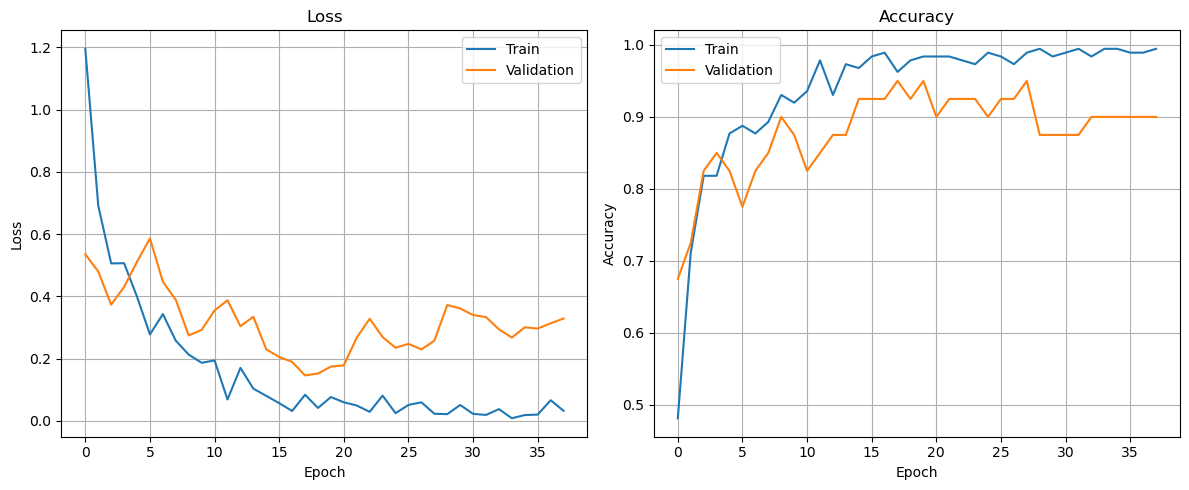

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
Accuracy : 0.7804878048780488
Precision: 0.7894736842105263
Recall   : 0.75
F1 Score : 0.7692307692307693

Confusion Matrix
[[17  4]
 [ 5 15]]

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.81      0.79        21
           1       0.79      0.75      0.77        20

    accuracy                           0.78        41
   macro avg       0.78      0.78      0.78        41
weighted avg       0.78      0.78      0.78        41



In [130]:
plot_history(history)
from sklearn.metrics import *

y_prob = eegnet_fft.predict(

    {

        "EEG": X_test_eeg,

        "FFT": X_test_fft

    }

)

y_pred = (y_prob > 0.5).astype(int).flatten()

print("="*50)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

In [179]:
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    SeparableConv2D,
    BatchNormalization,
    AveragePooling2D,
    Dropout,
    Flatten,
    Dense,
    Activation
)

from tensorflow.keras.constraints import max_norm

from tensorflow.keras.callbacks import EarlyStopping

In [178]:
def build_eegnet():

    input1 = Input(shape=(6,896,1))

    # Block 1


    x = Conv2D(
        filters=8,
        kernel_size=(1,64),
        padding='same',
        use_bias=False
    )(input1)

    x = BatchNormalization()(x)

    x = DepthwiseConv2D(
        kernel_size=(6,1),
        depth_multiplier=2,
        use_bias=False,
        depthwise_constraint=max_norm(1.)
    )(x)

    x = BatchNormalization()(x)

    x = Activation('elu')(x)

    x = AveragePooling2D(
        pool_size=(1,4)
    )(x)

    x = Dropout(0.5)(x)

    # Block 2

    x = SeparableConv2D(
        filters=16,
        kernel_size=(1,16),
        padding='same',
        use_bias=False
    )(x)

    x = BatchNormalization()(x)

    x = Activation('elu')(x)

    x = AveragePooling2D(
        pool_size=(1,8)
    )(x)

    x = Dropout(0.5)(x)

    # Classification

    x = Flatten()(x)

    output = Dense(
        1,
        activation='sigmoid',
        kernel_constraint=max_norm(0.25)
    )(x)

    model = Model(
        inputs=input1,
        outputs=output
    )

    model.compile(

        optimizer='adam',

        loss='binary_crossentropy',

        metrics=['accuracy']

    )

    return model

In [180]:
SEED = 42

kfold = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=SEED

)

In [181]:
acc_list = []

precision_list = []

recall_list = []

f1_list = []

In [182]:
fold = 1

for train_index, test_index in kfold.split(X, y):

    print("="*60)
    print(f"Fold {fold}")
    print("="*60)

    # Split

    X_train = X[train_index]
    X_test = X[test_index]

    y_train = y[train_index]
    y_test = y[test_index]

    # Validation

    X_train, X_valid, y_train, y_valid = train_test_split(

        X_train,

        y_train,

        test_size=0.15,

        stratify=y_train,

        random_state=42

    )

    # EEGNet Shape

    X_train = X_train[..., np.newaxis]

    X_valid = X_valid[..., np.newaxis]

    X_test = X_test[..., np.newaxis]

    # Model

    model = build_eegnet()

    # EarlyStopping

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=15,

        restore_best_weights=True,

        verbose=0

    )

    # Train

    history = model.fit(

        X_train,

        y_train,

        validation_data=(

            X_valid,

            y_valid

        ),

        epochs=100,

        batch_size=16,

        callbacks=[early_stop],

        verbose=0

    )

    # Predict

    y_prob = model.predict(

        X_test,

        verbose=0

    )

    y_pred = (y_prob > 0.5).astype(int).flatten()
    
    # Metrics

    acc = accuracy_score(y_test, y_pred)

    pre = precision_score(y_test, y_pred)

    rec = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Save

    acc_list.append(acc)

    precision_list.append(pre)

    recall_list.append(rec)

    f1_list.append(f1)

    # Print

    print(f"Accuracy : {acc:.4f}")

    print(f"Precision: {pre:.4f}")

    print(f"Recall   : {rec:.4f}")

    print(f"F1 Score : {f1:.4f}")

    print()

    fold += 1

Fold 1
Accuracy : 0.7963
Precision: 0.9000
Recall   : 0.6667
F1 Score : 0.7660

Fold 2
Accuracy : 0.8704
Precision: 0.8571
Recall   : 0.8889
F1 Score : 0.8727

Fold 3
Accuracy : 0.8889
Precision: 0.8889
Recall   : 0.8889
F1 Score : 0.8889

Fold 4
Accuracy : 0.8868
Precision: 0.8846
Recall   : 0.8846
F1 Score : 0.8846

Fold 5
Accuracy : 0.8491
Precision: 0.9091
Recall   : 0.7692
F1 Score : 0.8333



In [184]:
print("="*60)

print("Final Results")

print("="*60)

print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")

print(f"Precision: {np.mean(precision_list):.4f}")

print(f"Recall   : {np.mean(recall_list):.4f}")

print(f"F1 Score : {np.mean(f1_list):.4f}")

Final Results
Accuracy : 0.8583 ± 0.0341
Precision: 0.8879
Recall   : 0.8197
F1 Score : 0.8491
